
# Stage 1 — Banana Tree Detection (YOLOv8)

**Task:** Bounding-box detection of `banana_tree` in field photos (single class today; the
pipeline is written to extend cleanly to `banana_tree` vs `non_banana_tree` the moment your
friend's negative-class annotations arrive — see the note in Section 3).

## Design decisions and why (read this before running)

| Decision | Choice | Why |
|---|---|---|
| Model | YOLOv8n (nano), YOLOv8s toggle available | Fits comfortably in 4GB VRAM (RTX 3050 Laptop); anchor-free, fast to converge on small datasets via transfer learning |
| Input resolution | 512×512 | Matches the majority native size of your source images; keeps memory budget safe |
| Pretrained weights | COCO-pretrained `yolov8n.pt` | 113 images is too small to train a detector from scratch — transfer learning is mandatory here |
| Optimizer | AdamW | Converges faster than SGD with fewer epochs on small custom datasets |
| LR schedule | Cosine annealing + 3-epoch warmup | Standard for fine-tuning; avoids early instability from a too-high LR on a pretrained model |
| Augmentation | Mosaic + light MixUp + HSV + geometric jitter | Small dataset (113 imgs) needs heavy augmentation to avoid overfitting. `flipud=0` (no vertical flip) since trees have a consistent gravity-correct orientation — an upside-down tree is not a realistic sample |
| Train/val/test split | **Group-aware** 70/15/15 | **Critical finding:** your 113 images come from only 71 unique source photos — Roboflow's rotation/augmentation step created near-duplicate copies of the same photo. A naive random split would leak near-identical images across train/val/test and inflate your validation score. We split by *original photo identity*, not by file, so no source photo appears in more than one split. |
| Mixed precision | FP16 (AMP), on by default in Ultralytics | ~2x memory savings, lets us use a larger batch size on 4GB VRAM |
| Early stopping | Patience = 30 epochs on no mAP improvement | Prevents wasted compute / overfitting once the model plateaus |

**Assumption stated up front:** since only 113 images / 1 class exist right now, class-imbalance
handling (oversampling, class weights) is deferred — there's nothing to balance yet. Section 3 has
a clearly marked hook for when the `non_banana_tree` class arrives.


## 0. Environment Setup

In [2]:

# Run once. If you're in a fresh virtual environment, this installs everything needed.
# On Windows, run this cell, then RESTART the kernel before continuing if this is a first install.
%pip install ultralytics scikit-learn matplotlib seaborn pillow opencv-python thop --quiet


Note: you may need to restart the kernel to use updated packages.


In [3]:

import os
import json
import random
import shutil
import time
from pathlib import Path
from collections import defaultdict, Counter

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import cv2
from PIL import Image
from sklearn.model_selection import GroupShuffleSplit

import torch
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("VRAM (GB):", round(torch.cuda.get_device_properties(0).total_memory / 1e9, 2))

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)


Torch version: 2.14.0+cpu
CUDA available: False



## 1. Configuration

**Edit `RAW_IMAGES_DIR` and `COCO_JSON_PATH` below to point at your local files.**
Everything else in this notebook reads from this single config cell — no other hard-coded paths.


In [4]:

# ---- EDIT THESE TWO PATHS ----
RAW_IMAGES_DIR = Path("./banana-tree-detection.coco/train")                          # images live here, next to the json
COCO_JSON_PATH = Path("./banana-tree-detection.coco/train/_annotations.coco.json")    # you already had this part right
# --------------------------------

WORK_DIR = Path("./stage1_work")             # <- changed, see note below
DATASET_DIR = WORK_DIR / "dataset"
RUNS_DIR = WORK_DIR / "runs"

IMG_SIZE = 512
MODEL_VARIANT = "yolov8n.pt"   # try "yolov8s.pt" if you have VRAM headroom and want more capacity
BATCH_SIZE = 16                # drop to 8 if you hit CUDA out-of-memory
EPOCHS = 150
PATIENCE = 30                  # early stopping patience (epochs with no mAP improvement)

SPLIT_RATIOS = dict(train=0.70, val=0.15, test=0.15)

for d in [WORK_DIR, DATASET_DIR, RUNS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

assert RAW_IMAGES_DIR.exists(), f"Image folder not found: {RAW_IMAGES_DIR.resolve()}"
assert COCO_JSON_PATH.exists(), f"Annotation file not found: {COCO_JSON_PATH.resolve()}"

with open(COCO_JSON_PATH) as f:
    coco = json.load(f)

print(f"Loaded {len(coco['images'])} images, {len(coco['annotations'])} annotations, "
      f"{len(coco['categories'])} categories.")


Loaded 113 images, 113 annotations, 2 categories.



## 2. Data Exploration (EDA)

### 2.1 Basic stats & category map


In [5]:

cat_id_to_name = {c["id"]: c["name"] for c in coco["categories"]}
print("Categories:", cat_id_to_name)

ann_per_image = Counter(a["image_id"] for a in coco["annotations"])
print(f"Images with exactly 1 box: {sum(1 for v in ann_per_image.values() if v == 1)}")
print(f"Images with >1 box: {sum(1 for v in ann_per_image.values() if v > 1)}")
print(f"Images with 0 boxes: {len(coco['images']) - len(ann_per_image)}")


Categories: {0: 'banana-plant-detection', 1: 'banana_tree'}
Images with exactly 1 box: 113
Images with >1 box: 0
Images with 0 boxes: 0


### 2.2 Image size distribution

Roboflow's export mixes multiple sizes (rotation-augmented crops). We normalize this at training time via YOLO's letterbox resize to `IMG_SIZE`, so variable input sizes are not a problem — but it's worth seeing the spread.

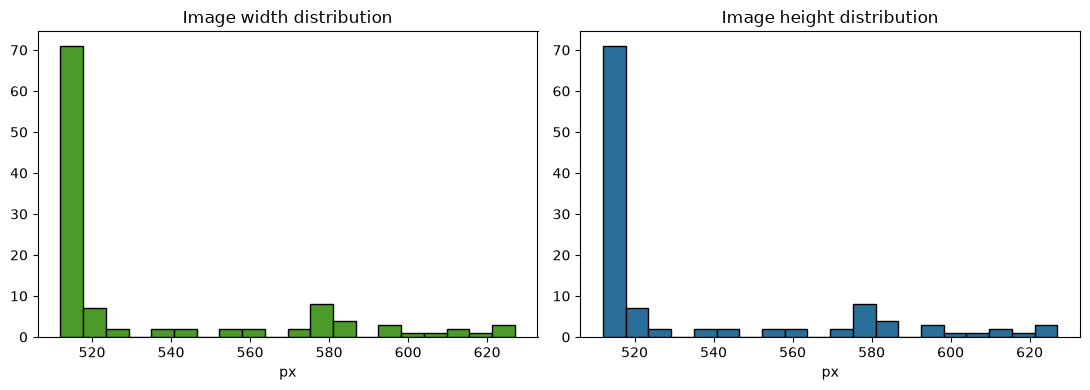

Width  range: 512–627 (median 512)
Height range: 512–627 (median 512)


In [6]:

widths = [img["width"] for img in coco["images"]]
heights = [img["height"] for img in coco["images"]]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(widths, bins=20, color="#4C9A2A", edgecolor="black")
axes[0].set_title("Image width distribution")
axes[0].set_xlabel("px")
axes[1].hist(heights, bins=20, color="#2A6F9A", edgecolor="black")
axes[1].set_title("Image height distribution")
axes[1].set_xlabel("px")
plt.tight_layout()
plt.show()

print(f"Width  range: {min(widths)}–{max(widths)} (median {int(np.median(widths))})")
print(f"Height range: {min(heights)}–{max(heights)} (median {int(np.median(heights))})")


### 2.3 Box size / aspect ratio / relative area

Understanding how big the banana_tree box typically is relative to the image helps sanity-check `IMG_SIZE` choice (too-small `IMG_SIZE` would shrink small objects past recognition).

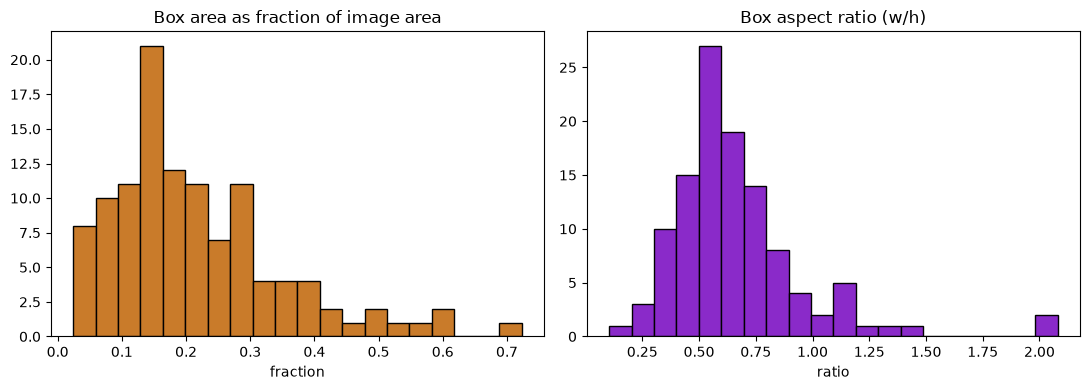

Median box covers 18.6% of the image
Median aspect ratio (w/h): 0.60 (tall/narrow boxes are typical for tree trunks+canopy)


In [7]:

img_dims = {img["id"]: (img["width"], img["height"]) for img in coco["images"]}

rel_areas, aspect_ratios = [], []
for a in coco["annotations"]:
    w_img, h_img = img_dims[a["image_id"]]
    x, y, w, h = a["bbox"]
    rel_areas.append((w * h) / (w_img * h_img))
    aspect_ratios.append(w / h if h > 0 else 0)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(rel_areas, bins=20, color="#C97B2A", edgecolor="black")
axes[0].set_title("Box area as fraction of image area")
axes[0].set_xlabel("fraction")
axes[1].hist(aspect_ratios, bins=20, color="#8A2AC9", edgecolor="black")
axes[1].set_title("Box aspect ratio (w/h)")
axes[1].set_xlabel("ratio")
plt.tight_layout()
plt.show()

print(f"Median box covers {np.median(rel_areas)*100:.1f}% of the image")
print(f"Median aspect ratio (w/h): {np.median(aspect_ratios):.2f} (tall/narrow boxes are typical for tree trunks+canopy)")


### 2.4 Visualize sample images with ground-truth boxes

This is a correctness check as much as an exploration step — if boxes look misaligned here, something is wrong with the annotation file or image ordering before we go any further.

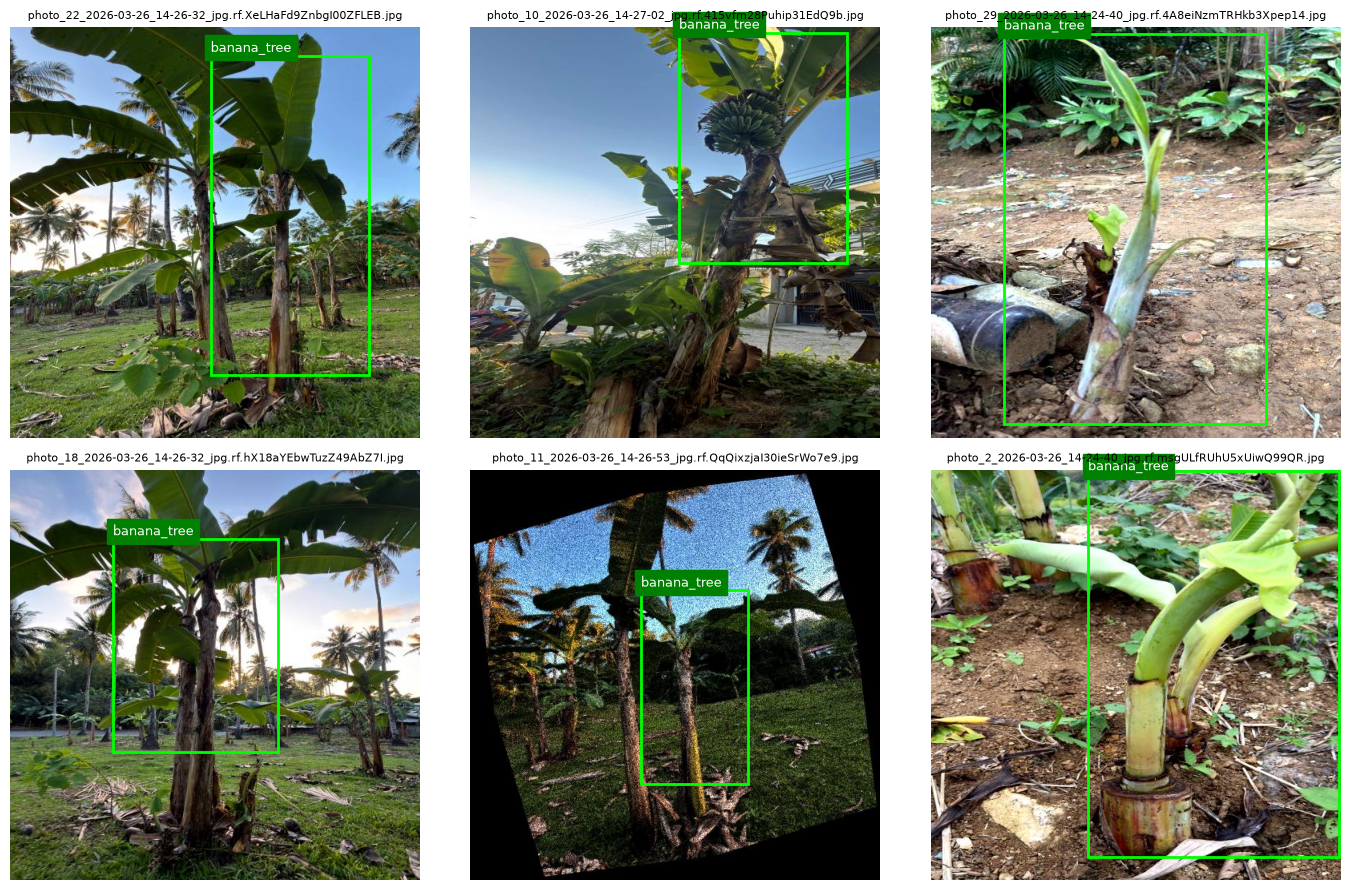

In [8]:

def draw_boxes_for_image(image_id, ax=None):
    img_info = next(i for i in coco["images"] if i["id"] == image_id)
    img_path = RAW_IMAGES_DIR / img_info["file_name"]
    if not img_path.exists():
        print(f"[skip] file not found locally: {img_path}")
        return
    im = Image.open(img_path).convert("RGB")
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 5))
    ax.imshow(im)
    for a in coco["annotations"]:
        if a["image_id"] != image_id:
            continue
        x, y, w, h = a["bbox"]
        rect = patches.Rectangle((x, y), w, h, linewidth=2, edgecolor="lime", facecolor="none")
        ax.add_patch(rect)
        ax.text(x, max(y - 5, 0), cat_id_to_name[a["category_id"]],
                 color="white", fontsize=9, backgroundcolor="green")
    ax.set_title(img_info["file_name"], fontsize=8)
    ax.axis("off")

sample_ids = random.sample([i["id"] for i in coco["images"]], k=min(6, len(coco["images"])))
fig, axes = plt.subplots(2, 3, figsize=(14, 9))
for image_id, ax in zip(sample_ids, axes.ravel()):
    draw_boxes_for_image(image_id, ax=ax)
plt.tight_layout()
plt.show()



### 2.5 Data-leakage check: augmented duplicates

Roboflow's `extra.name` field stores the *original* photo filename before rotation/augmentation.
If the same original photo appears multiple times (as different crops/rotations), a naive random
split can put near-duplicates of the same photo into both train and val/test — which quietly
inflates your validation metrics. Let's quantify this on your actual data.


In [9]:

original_names = [img["extra"]["name"] if "extra" in img and "name" in img["extra"] else img["file_name"]
                  for img in coco["images"]]
name_counts = Counter(original_names)
dupes = {k: v for k, v in name_counts.items() if v > 1}

print(f"Total images: {len(coco['images'])}")
print(f"Unique original source photos: {len(name_counts)}")
print(f"Source photos with multiple augmented copies: {len(dupes)}")
print(f"Total 'duplicate' images from augmentation: {sum(dupes.values())}")
print()
print("--> This is why the split in Section 3 groups by original photo identity, not by file.")


Total images: 113
Unique original source photos: 71
Source photos with multiple augmented copies: 41
Total 'duplicate' images from augmentation: 83

--> This is why the split in Section 3 groups by original photo identity, not by file.



## 3. Data Preprocessing

### 3.1 Group-aware train / val / test split

We split by **original photo group** (from `extra.name`) so that all augmented copies of the same
source photo land in the *same* split. `GroupShuffleSplit` doesn't guarantee exact ratios when group
sizes vary (some photos have 1 copy, some have 2–3) — so we search a handful of seeds and keep the one
whose resulting split is closest to the target ratios, while still asserting zero group overlap.


In [10]:

image_ids = [img["id"] for img in coco["images"]]
groups = [img["extra"]["name"] if "extra" in img and "name" in img["extra"] else img["file_name"]
          for img in coco["images"]]

def try_group_split(seed, train_size_1=0.8, train_size_2=0.82):
    gss1 = GroupShuffleSplit(n_splits=1, train_size=train_size_1, random_state=seed)
    trainval_idx, test_idx = next(gss1.split(image_ids, groups=groups))
    trainval_groups = [groups[i] for i in trainval_idx]
    gss2 = GroupShuffleSplit(n_splits=1, train_size=train_size_2, random_state=seed)
    train_idx_rel, val_idx_rel = next(gss2.split(trainval_idx, groups=trainval_groups))
    train_idx = [trainval_idx[i] for i in train_idx_rel]
    val_idx = [trainval_idx[i] for i in val_idx_rel]
    return train_idx, val_idx, test_idx

best = None
for seed in range(60):
    train_idx, val_idx, test_idx = try_group_split(seed)
    total = len(train_idx) + len(val_idx) + len(test_idx)
    score = (abs(len(train_idx)/total - SPLIT_RATIOS["train"]) +
             abs(len(val_idx)/total - SPLIT_RATIOS["val"]) +
             abs(len(test_idx)/total - SPLIT_RATIOS["test"]))
    if best is None or score < best[0]:
        best = (score, seed, train_idx, val_idx, test_idx)

_, best_seed, train_idx, val_idx, test_idx = best
print(f"Best seed: {best_seed}")
print(f"train={len(train_idx)}  val={len(val_idx)}  test={len(test_idx)}  "
      f"(total={len(train_idx)+len(val_idx)+len(test_idx)})")

# Hard assertion: zero source-photo leakage across splits
train_groups = set(groups[i] for i in train_idx)
val_groups = set(groups[i] for i in val_idx)
test_groups = set(groups[i] for i in test_idx)
assert not (train_groups & val_groups), "LEAKAGE: train/val share a source photo"
assert not (train_groups & test_groups), "LEAKAGE: train/test share a source photo"
assert not (val_groups & test_groups), "LEAKAGE: val/test share a source photo"
print("No cross-split leakage confirmed.")

split_map = {}  # image_id -> "train"/"val"/"test"
for i in train_idx: split_map[image_ids[i]] = "train"
for i in val_idx:   split_map[image_ids[i]] = "val"
for i in test_idx:  split_map[image_ids[i]] = "test"


Best seed: 45
train=76  val=17  test=20  (total=113)
No cross-split leakage confirmed.


### 3.2 COCO → YOLO format conversion

YOLO expects one `.txt` label file per image, each line `class_id x_center y_center width height` normalized to [0, 1].

In [11]:

def coco_box_to_yolo(bbox, img_w, img_h):
    x, y, w, h = bbox
    cx = (x + w / 2) / img_w
    cy = (y + h / 2) / img_h
    nw = w / img_w
    nh = h / img_h
    return cx, cy, nw, nh

# Single class today. If your friend's non_banana_tree annotations arrive later,
# add the new category id here — everything downstream (data.yaml, training) adapts automatically.
CLASS_NAME_TO_ID = {"banana_tree": 0}
# --- HOOK for future negative class ---
# CLASS_NAME_TO_ID = {"banana_tree": 0, "non_banana_tree": 1}

img_id_to_info = {img["id"]: img for img in coco["images"]}
anns_by_image = defaultdict(list)
for a in coco["annotations"]:
    anns_by_image[a["image_id"]].append(a)

for split in ["train", "val", "test"]:
    (DATASET_DIR / "images" / split).mkdir(parents=True, exist_ok=True)
    (DATASET_DIR / "labels" / split).mkdir(parents=True, exist_ok=True)

n_copied, n_missing = 0, 0
for img_id, split in split_map.items():
    info = img_id_to_info[img_id]
    src_path = RAW_IMAGES_DIR / info["file_name"]
    if not src_path.exists():
        n_missing += 1
        continue
    dst_img = DATASET_DIR / "images" / split / info["file_name"]
    shutil.copy2(src_path, dst_img)
    n_copied += 1

    label_lines = []
    for a in anns_by_image.get(img_id, []):
        cname = cat_id_to_name[a["category_id"]]
        if cname not in CLASS_NAME_TO_ID:
            continue
        cid = CLASS_NAME_TO_ID[cname]
        cx, cy, nw, nh = coco_box_to_yolo(a["bbox"], info["width"], info["height"])
        label_lines.append(f"{cid} {cx:.6f} {cy:.6f} {nw:.6f} {nh:.6f}")

    dst_label = DATASET_DIR / "labels" / split / (Path(info["file_name"]).stem + ".txt")
    dst_label.write_text("\n".join(label_lines))

print(f"Copied {n_copied} images, {n_missing} missing from RAW_IMAGES_DIR (check the folder if this is > 0).")


Copied 113 images, 0 missing from RAW_IMAGES_DIR (check the folder if this is > 0).


### 3.3 Generate `data.yaml` for Ultralytics

In [12]:

names_sorted = [name for name, _ in sorted(CLASS_NAME_TO_ID.items(), key=lambda kv: kv[1])]
data_yaml_lines = [
    f"path: {DATASET_DIR.resolve()}",
    "train: images/train",
    "val: images/val",
    "test: images/test",
    f"nc: {len(names_sorted)}",
    f"names: {names_sorted}",
]
data_yaml = "\n".join(data_yaml_lines) + "\n"
data_yaml_path = WORK_DIR / "data.yaml"
data_yaml_path.write_text(data_yaml)
print(data_yaml)


path: C:\Users\saugat\Desktop\PRT691\stage1_work\dataset
train: images/train
val: images/val
test: images/test
nc: 1
names: ['banana_tree']



### 3.4 Sanity check: re-draw converted YOLO labels back onto images

If the round-trip (COCO → YOLO → back to pixel boxes) doesn't match Section 2.4's plot, stop here — something is wrong with the conversion, not the model.

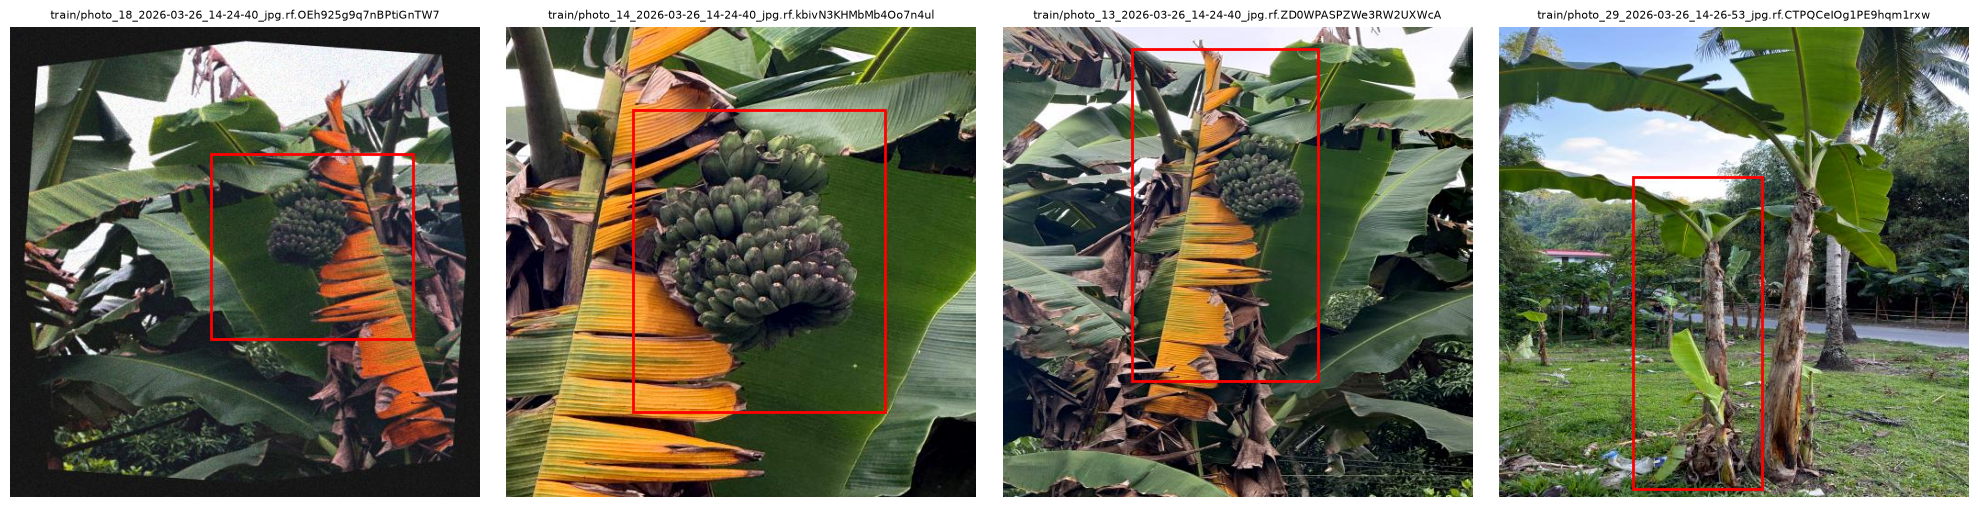

In [13]:

def draw_yolo_label(split, filename_stem, ax):
    img_path = DATASET_DIR / "images" / split / f"{filename_stem}.jpg"
    label_path = DATASET_DIR / "labels" / split / f"{filename_stem}.txt"
    im = Image.open(img_path).convert("RGB")
    w_img, h_img = im.size
    ax.imshow(im)
    for line in label_path.read_text().splitlines():
        cid, cx, cy, nw, nh = map(float, line.split())
        x = (cx - nw / 2) * w_img
        y = (cy - nh / 2) * h_img
        w = nw * w_img
        h = nh * h_img
        rect = patches.Rectangle((x, y), w, h, linewidth=2, edgecolor="red", facecolor="none")
        ax.add_patch(rect)
    ax.set_title(f"{split}/{filename_stem}", fontsize=8)
    ax.axis("off")

train_files = list((DATASET_DIR / "images" / "train").glob("*.jpg"))
sample_files = random.sample(train_files, k=min(4, len(train_files)))
fig, axes = plt.subplots(1, len(sample_files), figsize=(5*len(sample_files), 5))
if len(sample_files) == 1:
    axes = [axes]
for f, ax in zip(sample_files, axes):
    draw_yolo_label("train", f.stem, ax)
plt.tight_layout()
plt.show()



## 4. Architecture

**Backbone:** YOLOv8's CSPDarknet-style backbone with C2f blocks — good accuracy/speed tradeoff at
small size (nano ≈ 3.2M params, small ≈ 11.2M params).
**Head:** anchor-free, decoupled detection head (separate branches for classification and box
regression, as in YOLOv8/YOLOX-style designs) — removes the need to hand-tune anchor box priors,
which matters on a small, single-object-per-image dataset like this one.
**Why nano over small/medium:** at 4GB VRAM, nano leaves the most headroom for batch size and
`IMG_SIZE`; move up to `yolov8s.pt` only if training is stable and you want to trade some
speed for a small accuracy gain.

**Class-imbalance hook for later:** once `non_banana_tree` boxes are added, YOLO's per-anchor loss
does not require manual class weighting the way a plain classifier would — but if the negative class
ends up heavily under- or over-represented, revisit via `cls` loss gain in the train() call below, or
by oversampling minority-class images in `split_map`.


In [14]:

from ultralytics import YOLO

model = YOLO(MODEL_VARIANT)
model.info()  # prints layer count, parameter count, GFLOPs


Creating new Ultralytics Settings v0.0.8 file  
View Ultralytics Settings with 'yolo settings' or at 'C:\Users\saugat\AppData\Roaming\Ultralytics\settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
YOLOv8n summary: 129 layers, 3,157,200 parameters, 0 gradients


(129, 3157200, 0, 0.0)


## 5. Optimization & Training

| Component | Setting | Rationale |
|---|---|---|
| Loss | Ultralytics default: CIoU (box regression) + BCE (classification) + DFL (distribution focal loss) | Standard, battle-tested combination for anchor-free detectors — no need to reimplement |
| Optimizer | AdamW | Faster convergence on small fine-tuning datasets than SGD |
| LR | `lr0=1e-3`, cosine annealed to `lr0 * lrf`, 3-epoch linear warmup | Warmup avoids destabilizing pretrained weights; cosine anneal gives smooth convergence |
| Weight decay | `5e-4` | Standard regularization strength for AdamW at this LR |
| Batch size | 16 (nano) | Fits 4GB VRAM with AMP on; drop to 8 if you see CUDA OOM |
| Mixed precision | AMP on (default in Ultralytics) | ~2x memory savings, lets us keep batch size higher |
| Augmentation | mosaic=1.0, mixup=0.1, hsv jitter, ±15° rotation, translate/scale/shear, `fliplr=0.5`, `flipud=0` | Small dataset needs strong augmentation; no vertical flip since tree orientation is physically meaningful |
| Early stopping | `patience=30` | Stops training once val mAP plateaus, avoiding overfitting on 76 train images |


In [15]:

results = model.train(
    data=str(data_yaml_path),
    imgsz=IMG_SIZE,
    epochs=EPOCHS,
    batch=BATCH_SIZE,
    patience=PATIENCE,
    optimizer="AdamW",
    lr0=1e-3,
    lrf=0.01,
    cos_lr=True,
    warmup_epochs=3,
    weight_decay=5e-4,
    amp=True,
    mosaic=1.0,
    mixup=0.1,
    hsv_h=0.015, hsv_s=0.7, hsv_v=0.4,
    degrees=15, translate=0.1, scale=0.5, shear=2.0,
    fliplr=0.5, flipud=0.0,
    seed=SEED,
    project=str(RUNS_DIR),
    name="banana_tree_detector",
    exist_ok=True,
)


Ultralytics 8.4.149  Python-3.14.4 torch-2.14.0+cpu CPU (AMD Ryzen 7 4800H with Radeon Graphics)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=stage1_work\data.yaml, degrees=15, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=150, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=banana_tree_detector, nbs=64, nms=None, ops

### 5.1 Training curves

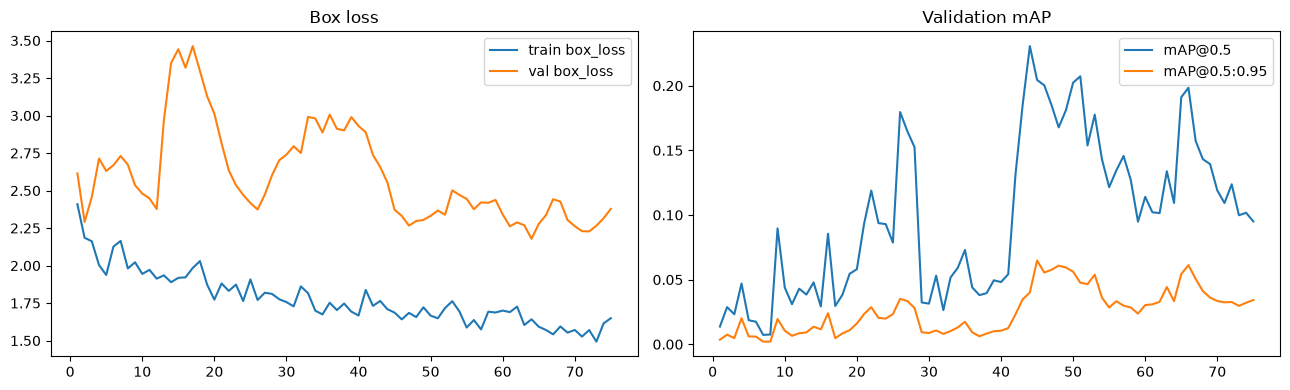

In [16]:

import pandas as pd

results_csv = Path(results.save_dir) / "results.csv"
df = pd.read_csv(results_csv)
df.columns = [c.strip() for c in df.columns]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(df["epoch"], df["train/box_loss"], label="train box_loss")
axes[0].plot(df["epoch"], df["val/box_loss"], label="val box_loss")
axes[0].set_title("Box loss"); axes[0].legend()
axes[1].plot(df["epoch"], df["metrics/mAP50(B)"], label="mAP@0.5")
axes[1].plot(df["epoch"], df["metrics/mAP50-95(B)"], label="mAP@0.5:0.95")
axes[1].set_title("Validation mAP"); axes[1].legend()
plt.tight_layout()
plt.show()



## 6. Evaluation

### 6.1 Test-set metrics (mAP, precision, recall)


In [17]:

best_weights = Path(results.save_dir) / "weights" / "best.pt"
eval_model = YOLO(str(best_weights))

metrics = eval_model.val(data=str(data_yaml_path), split="test", imgsz=IMG_SIZE)
print(f"mAP50:     {metrics.box.map50:.4f}")
print(f"mAP50-95:  {metrics.box.map:.4f}")
print(f"Precision: {metrics.box.mp:.4f}")
print(f"Recall:    {metrics.box.mr:.4f}")


Ultralytics 8.4.149  Python-3.14.4 torch-2.14.0+cpu CPU (AMD Ryzen 7 4800H with Radeon Graphics)
Model summary (fused): 72 layers, 3,005,843 parameters, 0 gradients
WARNING val: Slow image access detected (ping: 0.10.0 ms, read: 9.14.0 MB/s, size: 82.3 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips
val: Scanning C:\Users\saugat\Desktop\PRT691\stage1_work\dataset\labels\test... 20 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 20/20 380.2it/s 0.1s
val: New cache created: C:\Users\saugat\Desktop\PRT691\stage1_work\dataset\labels\test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 2.5it/s 0.8s1.9s
                   all         20         20      0.222      0.385      0.195     0.0655
Speed: 1.0ms preprocess, 33.9ms inference, 0.0ms loss, 0.6ms postprocess per image
Results saved to C:\Users\saugat\Desktop\PRT691\runs\det

### 6.2 Confusion matrix

Ultralytics auto-saves this during `val()`.

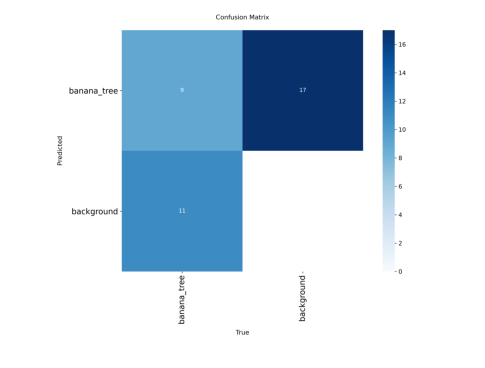

In [18]:

cm_path = Path(metrics.save_dir) / "confusion_matrix.png"
if cm_path.exists():
    plt.figure(figsize=(6, 6))
    plt.imshow(Image.open(cm_path))
    plt.axis("off")
    plt.show()
else:
    print("Confusion matrix image not found at", cm_path)



### 6.3 Confidence threshold sweep

`mAP` averages over many thresholds internally — but at **deployment** you pick one fixed
confidence threshold. Here we manually match predictions to ground truth (IoU ≥ 0.5) across a
range of confidence thresholds and plot precision/recall/F1, so you can pick a threshold that
matches your actual use case (e.g., favor recall if missing a tree is worse than a false alarm).


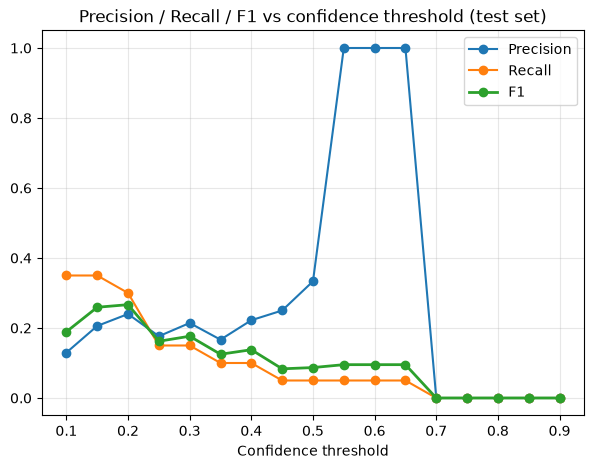

Best F1=0.267 at confidence threshold=0.20 (precision=0.240, recall=0.300)


In [19]:

def iou_xyxy(box1, box2):
    x1 = max(box1[0], box2[0]); y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2]); y2 = min(box1[3], box2[3])
    inter = max(0, x2 - x1) * max(0, y2 - y1)
    area1 = (box1[2]-box1[0]) * (box1[3]-box1[1])
    area2 = (box2[2]-box2[0]) * (box2[3]-box2[1])
    union = area1 + area2 - inter
    return inter / union if union > 0 else 0

test_files = sorted((DATASET_DIR / "images" / "test").glob("*.jpg"))

def load_gt_boxes(stem):
    label_path = DATASET_DIR / "labels" / "test" / f"{stem}.txt"
    im = Image.open(DATASET_DIR / "images" / "test" / f"{stem}.jpg")
    w_img, h_img = im.size
    boxes = []
    if label_path.exists():
        for line in label_path.read_text().splitlines():
            if not line.strip():
                continue
            cid, cx, cy, nw, nh = map(float, line.split())
            x1 = (cx - nw/2) * w_img; y1 = (cy - nh/2) * h_img
            x2 = (cx + nw/2) * w_img; y2 = (cy + nh/2) * h_img
            boxes.append((x1, y1, x2, y2))
    return boxes

conf_thresholds = np.arange(0.1, 0.95, 0.05)
precisions, recalls, f1s = [], [], []

all_preds = eval_model.predict(source=str(DATASET_DIR / "images" / "test"),
                                imgsz=IMG_SIZE, conf=0.01, iou=0.5, verbose=False)
pred_by_stem = {Path(p.path).stem: p for p in all_preds}

for thresh in conf_thresholds:
    tp, fp, fn = 0, 0, 0
    for f in test_files:
        gt_boxes = load_gt_boxes(f.stem)
        pred = pred_by_stem.get(f.stem)
        pred_boxes = []
        if pred is not None:
            for box, conf in zip(pred.boxes.xyxy.cpu().numpy(), pred.boxes.conf.cpu().numpy()):
                if conf >= thresh:
                    pred_boxes.append(tuple(box))
        matched_gt = set()
        for pb in pred_boxes:
            best_iou, best_j = 0, -1
            for j, gb in enumerate(gt_boxes):
                if j in matched_gt:
                    continue
                iou = iou_xyxy(pb, gb)
                if iou > best_iou:
                    best_iou, best_j = iou, j
            if best_iou >= 0.5:
                tp += 1
                matched_gt.add(best_j)
            else:
                fp += 1
        fn += len(gt_boxes) - len(matched_gt)

    p = tp / (tp + fp) if (tp + fp) > 0 else 0
    r = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * p * r / (p + r) if (p + r) > 0 else 0
    precisions.append(p); recalls.append(r); f1s.append(f1)

plt.figure(figsize=(7, 5))
plt.plot(conf_thresholds, precisions, label="Precision", marker="o")
plt.plot(conf_thresholds, recalls, label="Recall", marker="o")
plt.plot(conf_thresholds, f1s, label="F1", marker="o", linewidth=2)
plt.xlabel("Confidence threshold"); plt.legend(); plt.grid(alpha=0.3)
plt.title("Precision / Recall / F1 vs confidence threshold (test set)")
plt.show()

best_idx = int(np.argmax(f1s))
print(f"Best F1={f1s[best_idx]:.3f} at confidence threshold={conf_thresholds[best_idx]:.2f} "
      f"(precision={precisions[best_idx]:.3f}, recall={recalls[best_idx]:.3f})")



### 6.4 NMS IoU threshold

NMS suppresses duplicate overlapping boxes *for the same object*. With exactly one box per image in
the current dataset, its effect is muted — but once images with multiple trees appear (or the
negative class is added), a too-low IoU threshold merges genuinely separate trees into one box, and a
too-high threshold leaves duplicate boxes on the same tree. We sweep it here so the effect is visible
and the right default is chosen before that matters.


In [20]:

nms_thresholds = [0.3, 0.5, 0.7, 0.9]
for nms_iou in nms_thresholds:
    preds = eval_model.predict(source=str(DATASET_DIR / "images" / "test"),
                                imgsz=IMG_SIZE, conf=0.25, iou=nms_iou, verbose=False)
    avg_boxes = np.mean([len(p.boxes) for p in preds])
    print(f"NMS IoU={nms_iou:.1f}  ->  avg boxes/image = {avg_boxes:.2f}")


NMS IoU=0.3  ->  avg boxes/image = 0.70
NMS IoU=0.5  ->  avg boxes/image = 0.85
NMS IoU=0.7  ->  avg boxes/image = 1.65
NMS IoU=0.9  ->  avg boxes/image = 5.25



## 7. Inference Speed Profiling (latency / FPS)

Benchmarked at the trained `IMG_SIZE`, batch=1 (realistic single-image deployment scenario), after a
short warmup to let CUDA kernels JIT-compile.


In [21]:

device = "cuda" if torch.cuda.is_available() else "cpu"
sample_img = str(test_files[0])

# Warmup
for _ in range(5):
    _ = eval_model.predict(sample_img, imgsz=IMG_SIZE, device=device, verbose=False)

n_runs = 30
t0 = time.perf_counter()
for _ in range(n_runs):
    _ = eval_model.predict(sample_img, imgsz=IMG_SIZE, device=device, verbose=False)
elapsed = time.perf_counter() - t0

latency_ms = (elapsed / n_runs) * 1000
fps = 1000 / latency_ms
print(f"Device: {device}")
print(f"Avg latency: {latency_ms:.1f} ms/image")
print(f"Throughput:  {fps:.1f} FPS")


Device: cpu
Avg latency: 32.3 ms/image
Throughput:  31.0 FPS



## 8. Edge-case / qualitative failure analysis

Visualizing predictions vs. ground truth on the test set to see *where* the model struggles —
this matters more than the aggregate mAP number for deciding whether the model is actually usable.


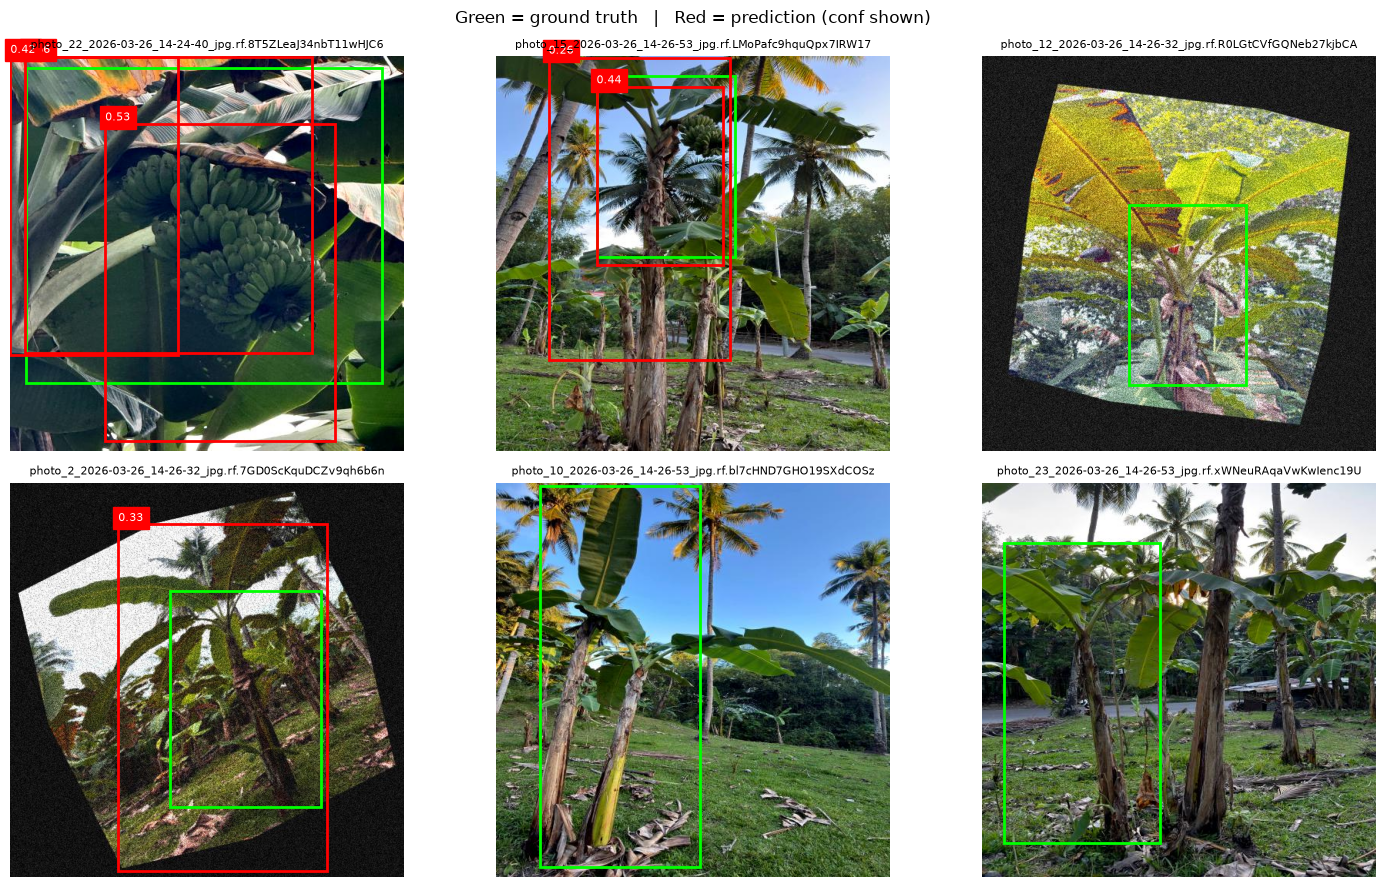

In [22]:

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
sample_test = random.sample(test_files, k=min(6, len(test_files)))
for f, ax in zip(sample_test, axes.ravel()):
    im = Image.open(f).convert("RGB")
    ax.imshow(im)
    # ground truth in green
    for gb in load_gt_boxes(f.stem):
        x1, y1, x2, y2 = gb
        ax.add_patch(patches.Rectangle((x1, y1), x2-x1, y2-y1, linewidth=2,
                                         edgecolor="lime", facecolor="none", label="GT"))
    # predictions in red
    pred = pred_by_stem.get(f.stem)
    if pred is not None:
        for box, conf in zip(pred.boxes.xyxy.cpu().numpy(), pred.boxes.conf.cpu().numpy()):
            if conf >= 0.25:
                x1, y1, x2, y2 = box
                ax.add_patch(patches.Rectangle((x1, y1), x2-x1, y2-y1, linewidth=2,
                                                 edgecolor="red", facecolor="none"))
                ax.text(x1, y1-5, f"{conf:.2f}", color="white", fontsize=8, backgroundcolor="red")
    ax.set_title(f.stem, fontsize=8)
    ax.axis("off")
plt.suptitle("Green = ground truth   |   Red = prediction (conf shown)")
plt.tight_layout()
plt.show()



**Known limitations to watch for given the current dataset:**
- Only 113 images from 71 source photos — expect the model to overfit to the specific lighting/
  background conditions in this set; validate on genuinely new photos before trusting it in the field.
- No negative class yet — the model has never seen a coconut palm or other non-banana plant labeled
  as such, so it may false-positive on visually similar trees until that data is added.
- Single box per image in training data — multi-tree scenes are untested territory; check qualitative
  results specifically on any multi-tree photo you have.


## 9. Save model & next steps

In [23]:

OUTPUT_DIR = Path("./stage1_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)
shutil.copy2(best_weights, OUTPUT_DIR / "banana_tree_detector_best.pt")
print(f"Saved: {OUTPUT_DIR / 'banana_tree_detector_best.pt'}")

# Optional: export to ONNX for lighter-weight deployment later
# eval_model.export(format="onnx", imgsz=IMG_SIZE)


Saved: stage1_outputs\banana_tree_detector_best.pt
